# ❤️ Heart Disease Prediction & Analysis

**Independent Data Science Project**
*Hala Wael Hagag — IBM Data Science Professional Certificate*

---

## Project Overview
This project applies the full data science workflow to predict whether a patient is at risk of heart disease, using the Cleveland Heart Disease dataset (UCI ML Repository, Detrano et al. 1989).

The dataset contains **303 patients** with **13 medical features** and a binary target (heart disease: yes/no).

### Skills Demonstrated
- Data loading & inspection
- Exploratory Data Analysis (EDA)
- Data visualization
- Feature preprocessing & scaling
- Multiple ML classification models with cross-validation
- Model evaluation: accuracy, confusion matrix, ROC/AUC


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, auc,
                              ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 1. Data Loading

In [2]:
# Load dataset (Cleveland Heart Disease — UCI ML Repository)
df = pd.read_csv('heart_disease.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Dataset shape: (303, 14)
Columns: ['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate', 'exercise_angina', 'st_depression', 'st_slope', 'num_vessels', 'thalassemia', 'target']


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,num_vessels,thalassemia,target
0,45,1,4,105,361,0,2,149,1,1.8,2,3,7,1
1,57,1,4,138,216,0,2,111,0,1.9,2,3,7,1
2,52,1,3,120,179,0,0,183,0,0.4,2,0,3,0
3,74,1,4,156,355,0,0,146,1,2.2,2,2,3,1
4,48,0,1,148,217,0,2,152,1,0.7,2,2,3,0


## 2. Dataset Overview

In [3]:
print("=== Data Types & Missing Values ===")
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'missing': df.isnull().sum()
})
print(info)


=== Data Types & Missing Values ===
                       dtype  non_null  missing
age                    int64       303        0
sex                    int64       303        0
chest_pain_type        int64       303        0
resting_bp             int64       303        0
cholesterol            int64       303        0
fasting_blood_sugar    int64       303        0
rest_ecg               int64       303        0
max_heart_rate         int64       303        0
exercise_angina        int64       303        0
st_depression        float64       303        0
st_slope               int64       303        0
num_vessels            int64       303        0
thalassemia            int64       303        0
target                 int64       303        0


In [4]:
print("=== Statistical Summary ===")
df.describe().T.round(2)


=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
age,303.0,53.99,8.88,29.0,48.0,54.0,60.0,77.0
sex,303.0,0.65,0.48,0.0,0.0,1.0,1.0,1.0
chest_pain_type,303.0,3.16,1.04,1.0,3.0,4.0,4.0,4.0
resting_bp,303.0,131.87,16.93,94.0,120.0,132.0,145.0,184.0
cholesterol,303.0,245.46,51.08,126.0,210.0,245.0,278.5,367.0
fasting_blood_sugar,303.0,0.14,0.35,0.0,0.0,0.0,0.0,1.0
rest_ecg,303.0,1.03,0.99,0.0,0.0,2.0,2.0,2.0
max_heart_rate,303.0,150.31,22.29,88.0,136.0,151.0,166.0,202.0
exercise_angina,303.0,0.39,0.49,0.0,0.0,0.0,1.0,1.0
st_depression,303.0,1.02,1.05,0.0,0.2,0.6,1.6,4.7


## 3. Exploratory Data Analysis

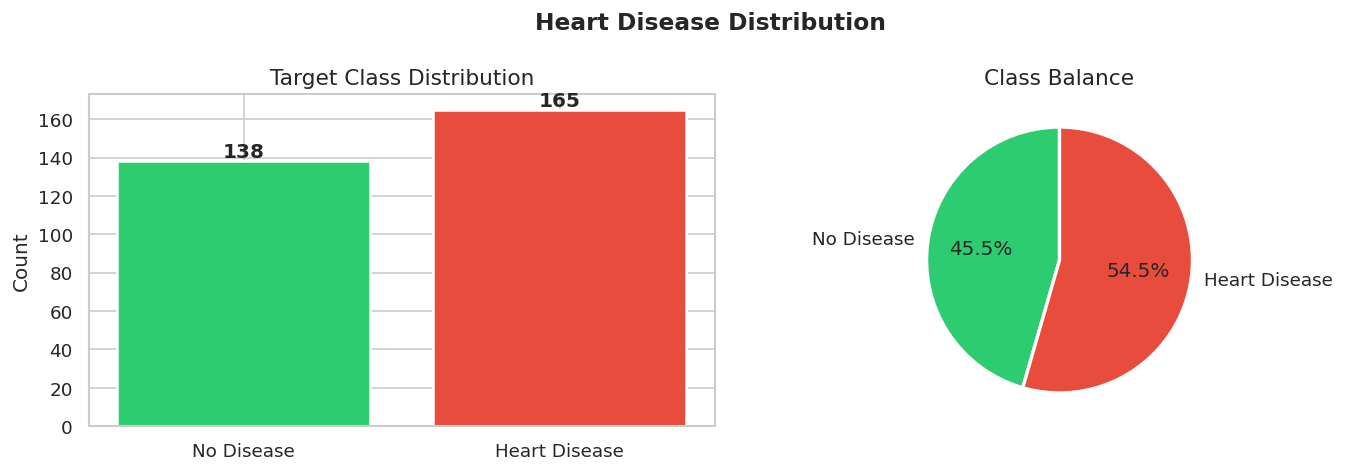

No Disease: 138  |  Heart Disease: 165


In [5]:
# ── Target class distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['target'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['No Disease', 'Heart Disease'], counts.values,
            color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Disease', 'Heart Disease'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance')

plt.suptitle('Heart Disease Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()
print(f"No Disease: {counts[0]}  |  Heart Disease: {counts[1]}")


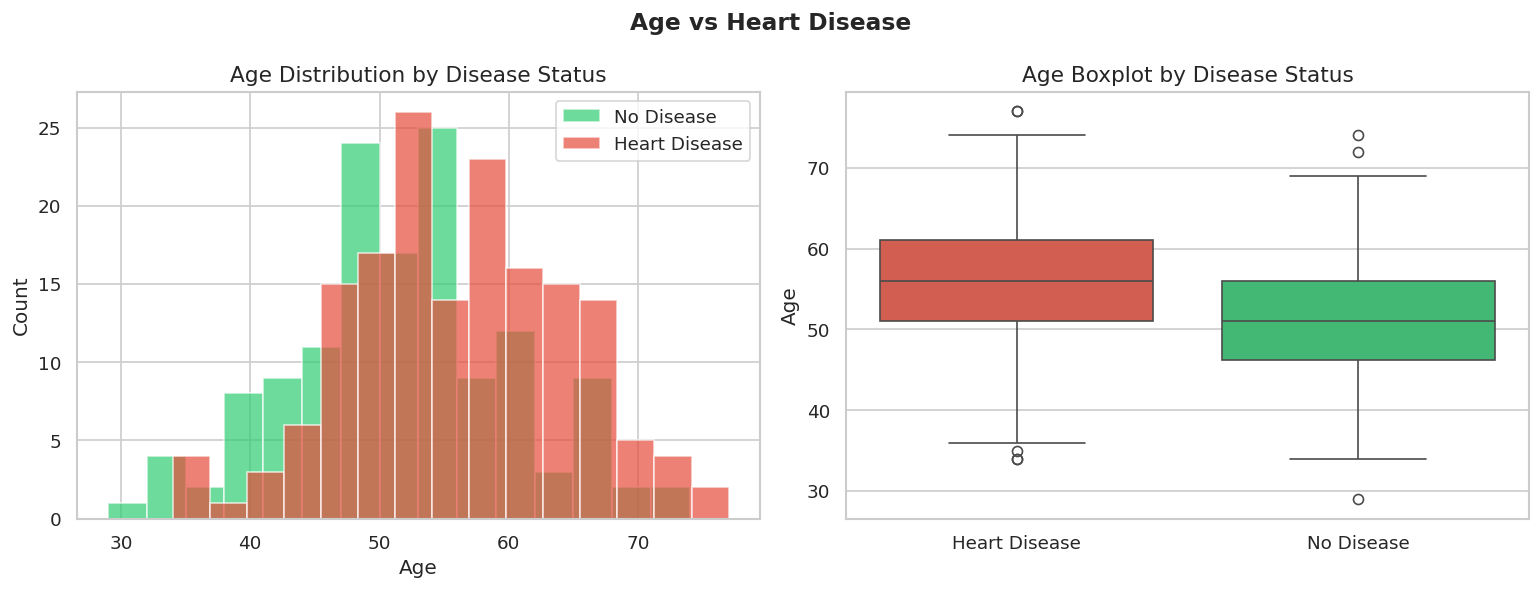

In [6]:
# ── Age distribution by disease status ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for target, color, label in [(0,'#2ecc71','No Disease'),(1,'#e74c3c','Heart Disease')]:
    axes[0].hist(df[df['target']==target]['age'], bins=15, alpha=0.7,
                 color=color, label=label, edgecolor='white')
axes[0].set_title('Age Distribution by Disease Status')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')
axes[0].legend()

df['_status'] = df['target'].map({0:'No Disease', 1:'Heart Disease'})
sns.boxplot(data=df, x='_status', y='age',
            palette={'No Disease':'#2ecc71','Heart Disease':'#e74c3c'}, ax=axes[1])
axes[1].set_title('Age Boxplot by Disease Status')
axes[1].set_xlabel(''); axes[1].set_ylabel('Age')
df.drop(columns=['_status'], inplace=True)

plt.suptitle('Age vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('age_distribution.png', bbox_inches='tight')
plt.show()


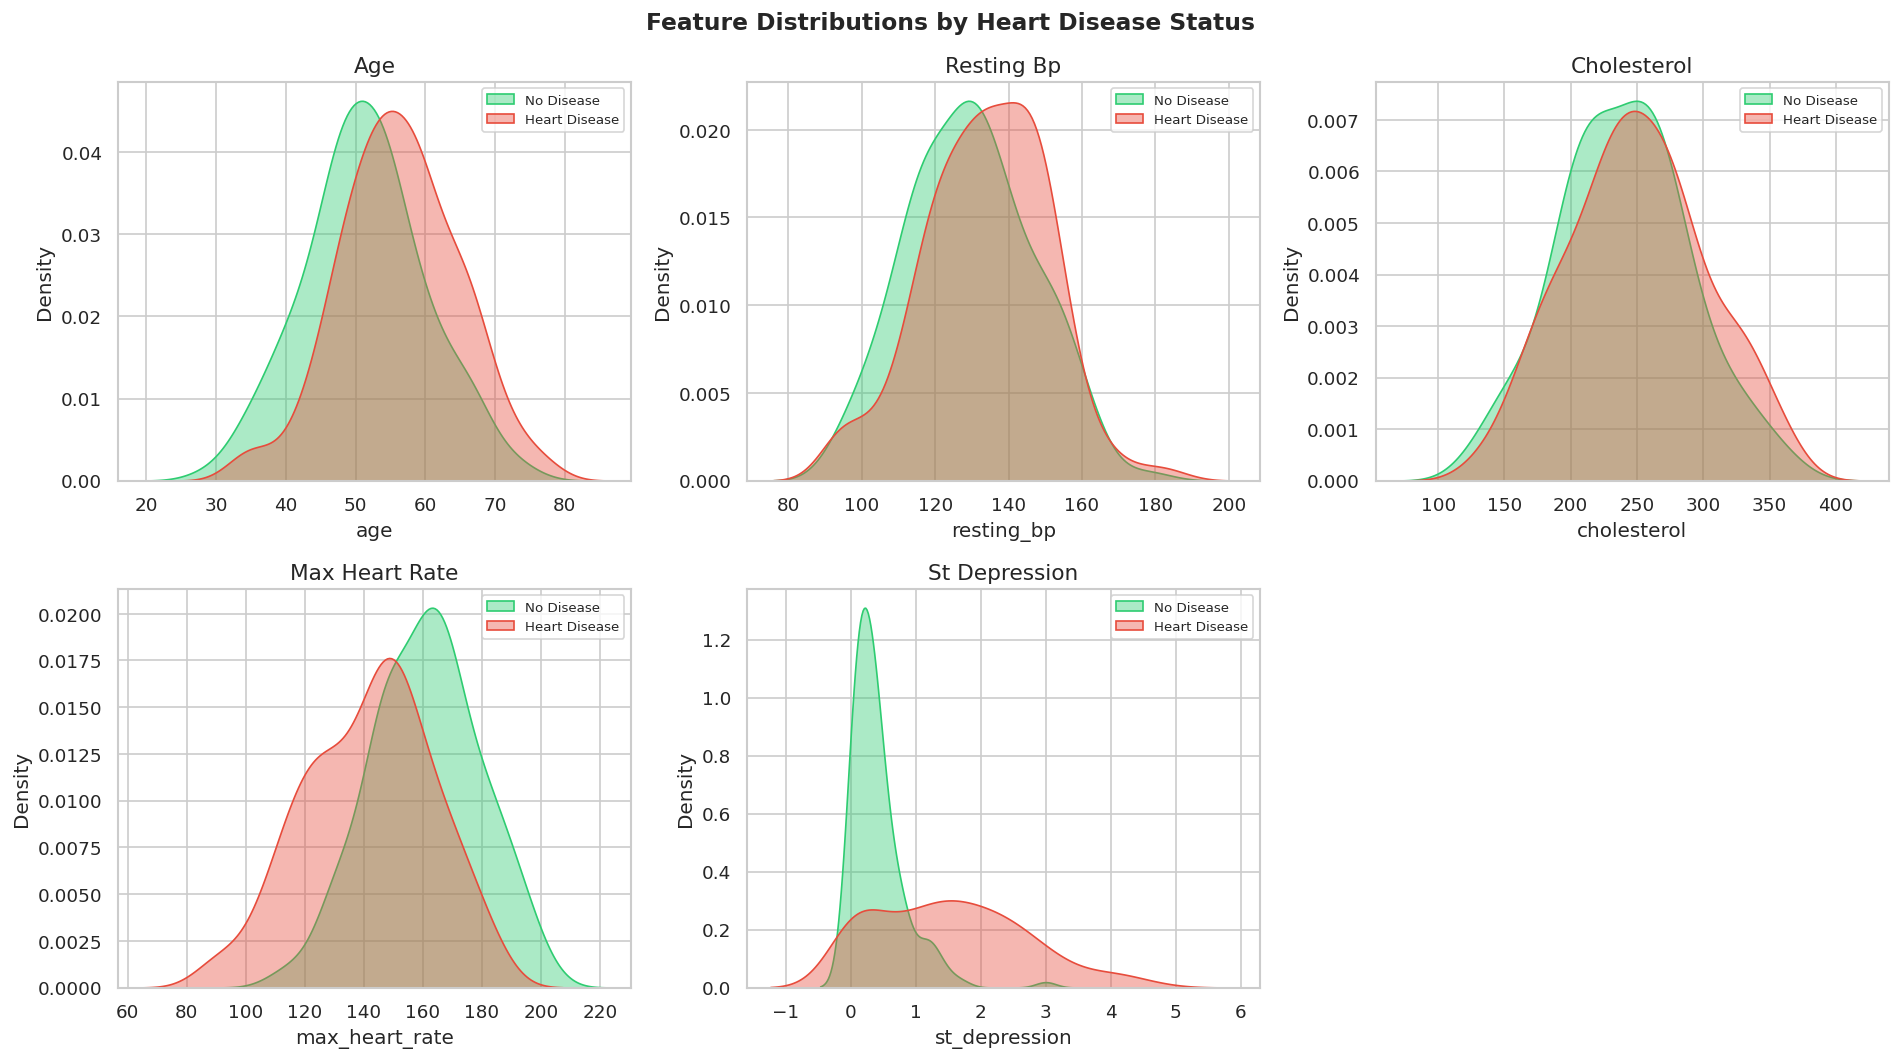

In [7]:
# ── Key numerical features: KDE plots ────────────────────────────────────────
num_features = ['age','resting_bp','cholesterol','max_heart_rate','st_depression']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    for target, color, label in [(0,'#2ecc71','No Disease'),(1,'#e74c3c','Heart Disease')]:
        sns.kdeplot(df[df['target']==target][feat].dropna(),
                    ax=axes[i], color=color, label=label, fill=True, alpha=0.4)
    axes[i].set_title(feat.replace('_',' ').title())
    axes[i].legend(fontsize=8)

axes[5].axis('off')
plt.suptitle('Feature Distributions by Heart Disease Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()


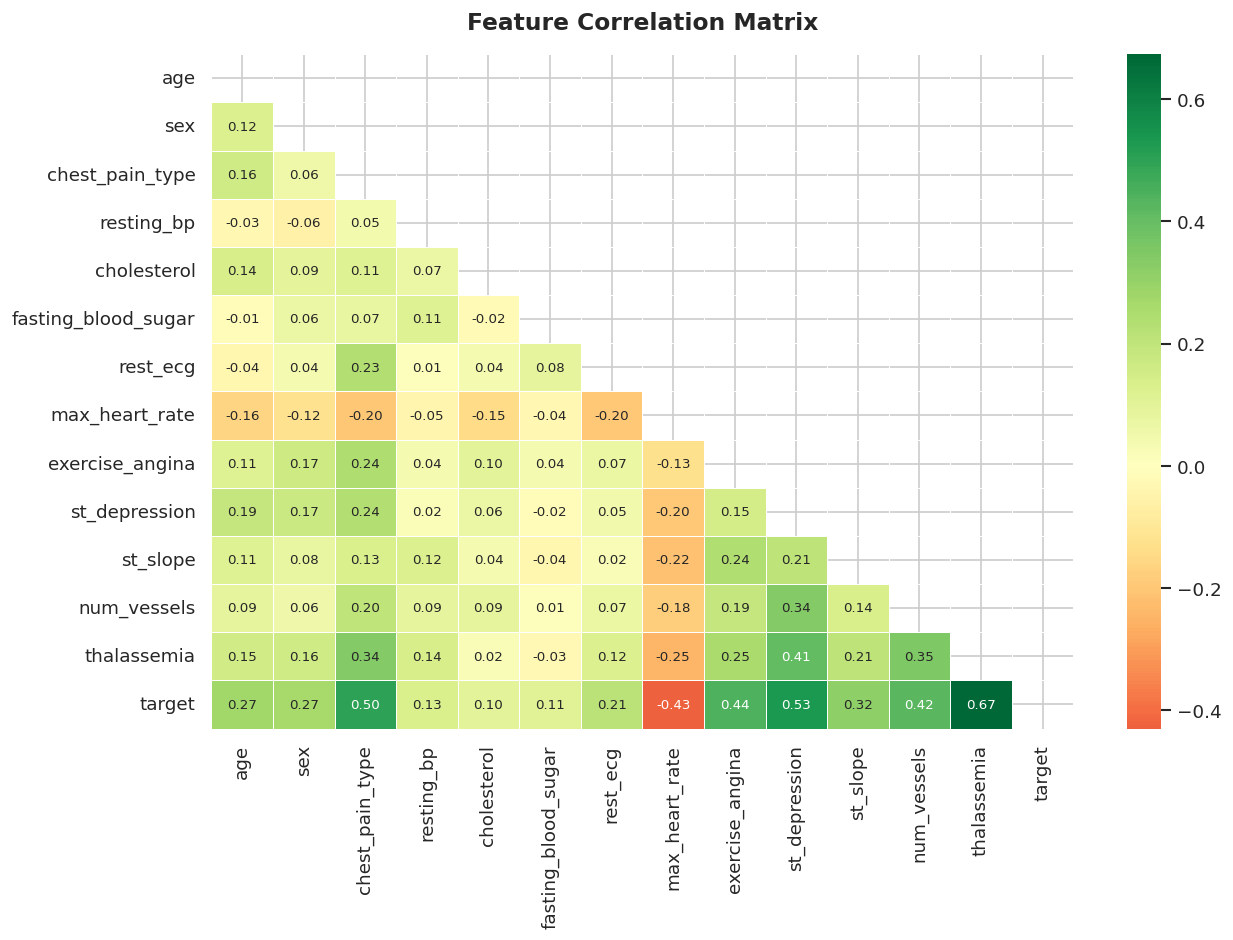


📊 Features most correlated with heart disease:
  ↑ thalassemia               0.674
  ↑ st_depression             0.532
  ↑ chest_pain_type           0.499
  ↑ exercise_angina           0.445
  ↓ max_heart_rate            0.430
  ↑ num_vessels               0.421
  ↑ st_slope                  0.318
  ↑ age                       0.273
  ↑ sex                       0.267
  ↑ rest_ecg                  0.215
  ↑ resting_bp                0.128
  ↑ fasting_blood_sugar       0.106
  ↑ cholesterol               0.098


In [8]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(11, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\n📊 Features most correlated with heart disease:")
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    direction = '↑' if corr['target'][feat] > 0 else '↓'
    print(f"  {direction} {feat:<25} {val:.3f}")


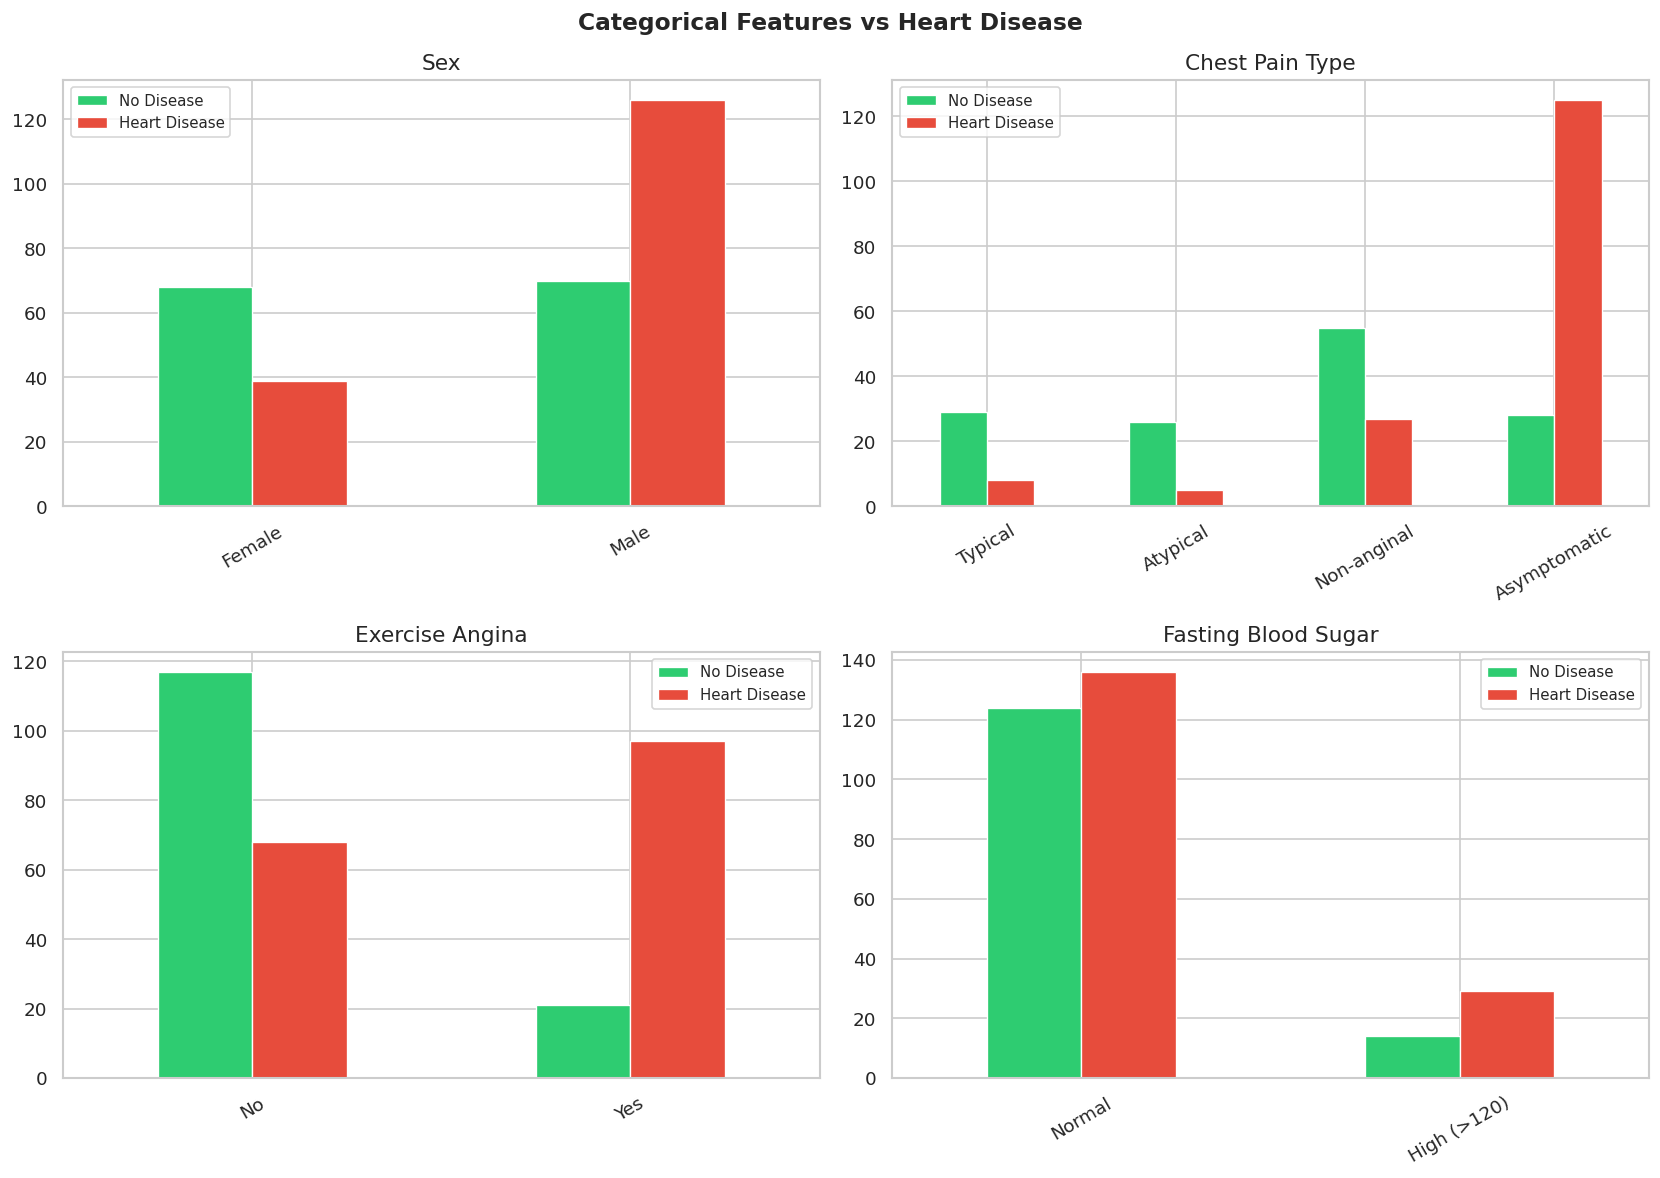

In [9]:
# ── Categorical features bar charts ──────────────────────────────────────────
cat_features = ['sex','chest_pain_type','exercise_angina','fasting_blood_sugar']
cat_labels = {
    'sex':                {0:'Female', 1:'Male'},
    'chest_pain_type':    {1:'Typical',2:'Atypical',3:'Non-anginal',4:'Asymptomatic'},
    'exercise_angina':    {0:'No', 1:'Yes'},
    'fasting_blood_sugar':{0:'Normal', 1:'High (>120)'}
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    data = df.groupby([feat, 'target']).size().unstack(fill_value=0)
    data.index = [cat_labels.get(feat,{}).get(idx, str(idx)) for idx in data.index]
    data.columns = ['No Disease','Heart Disease']
    data.plot(kind='bar', ax=axes[i], color=['#2ecc71','#e74c3c'],
              edgecolor='white', linewidth=0.8)
    axes[i].set_title(feat.replace('_',' ').title())
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=9)

plt.suptitle('Categorical Features vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_features.png', bbox_inches='tight')
plt.show()


## 4. Data Preprocessing

In [10]:
# Handle missing values
print(f"Missing values: {df.isnull().sum().sum()}")
df.fillna(df.median(numeric_only=True), inplace=True)

# Features & target
X = df.drop(columns=['target'])
y = df['target']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")
print(f"\nClass distribution in test set:")
print(y_test.value_counts().rename({0:'No Disease', 1:'Heart Disease'}))


Missing values: 0
Train: 242 samples  |  Test: 61 samples
Features: 13

Class distribution in test set:
target
Heart Disease    33
No Disease       28
Name: count, dtype: int64


## 5. Model Training & Evaluation

In [11]:
# Define 5 classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, kernel='rbf', random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=7)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f"{'Model':<22}  {'CV Accuracy':>12}  {'Std':>6}  {'Test Acc':>9}")
print("-" * 55)
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train_sc, y_train)
    y_pred   = model.predict(X_test_sc)
    test_acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'test_acc': test_acc, 'model': model, 'y_pred': y_pred
    }
    print(f"{name:<22}  {cv_scores.mean():>12.3f}  {cv_scores.std():>6.3f}  {test_acc:>9.3f}")


Model                    CV Accuracy     Std   Test Acc
-------------------------------------------------------
Logistic Regression            0.938   0.030      0.918
Decision Tree                  0.847   0.030      0.852


Random Forest                  0.921   0.031      0.918
SVM                            0.938   0.051      0.951
KNN                            0.913   0.048      0.918


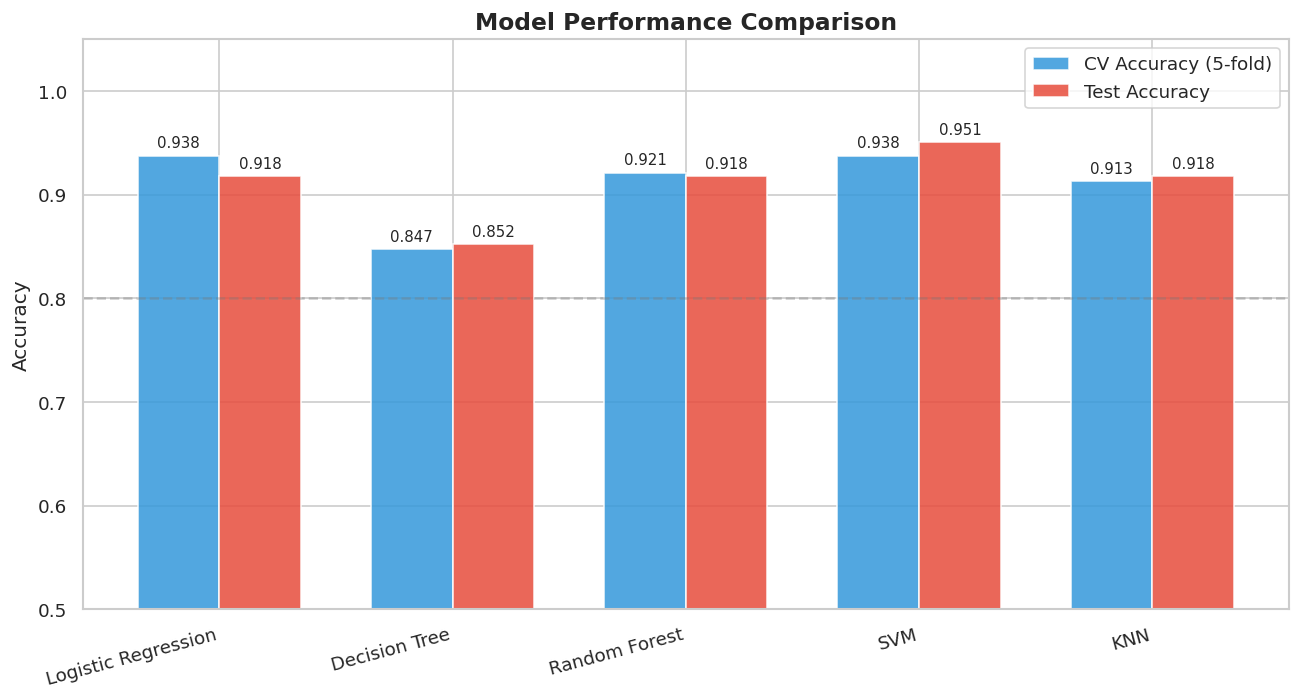

In [12]:
# ── Model comparison chart ────────────────────────────────────────────────────
names     = list(results.keys())
cv_means  = [results[n]['cv_mean']  for n in names]
test_accs = [results[n]['test_acc'] for n in names]
x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x-width/2, cv_means,  width, label='CV Accuracy (5-fold)', color='#3498db', alpha=0.85, edgecolor='white')
b2 = ax.bar(x+width/2, test_accs, width, label='Test Accuracy',         color='#e74c3c', alpha=0.85, edgecolor='white')

ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.4)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()


In [13]:
# Best model details
best_name = max(results, key=lambda n: results[n]['test_acc'])
best      = results[best_name]
print(f"🏆 Best Model: {best_name}  (Test Accuracy: {best['test_acc']:.4f})")
print()
print("=== Classification Report ===")
print(classification_report(y_test, best['y_pred'],
                             target_names=['No Disease','Heart Disease']))


🏆 Best Model: SVM  (Test Accuracy: 0.9508)

=== Classification Report ===
               precision    recall  f1-score   support

   No Disease       0.96      0.93      0.95        28
Heart Disease       0.94      0.97      0.96        33

     accuracy                           0.95        61
    macro avg       0.95      0.95      0.95        61
 weighted avg       0.95      0.95      0.95        61



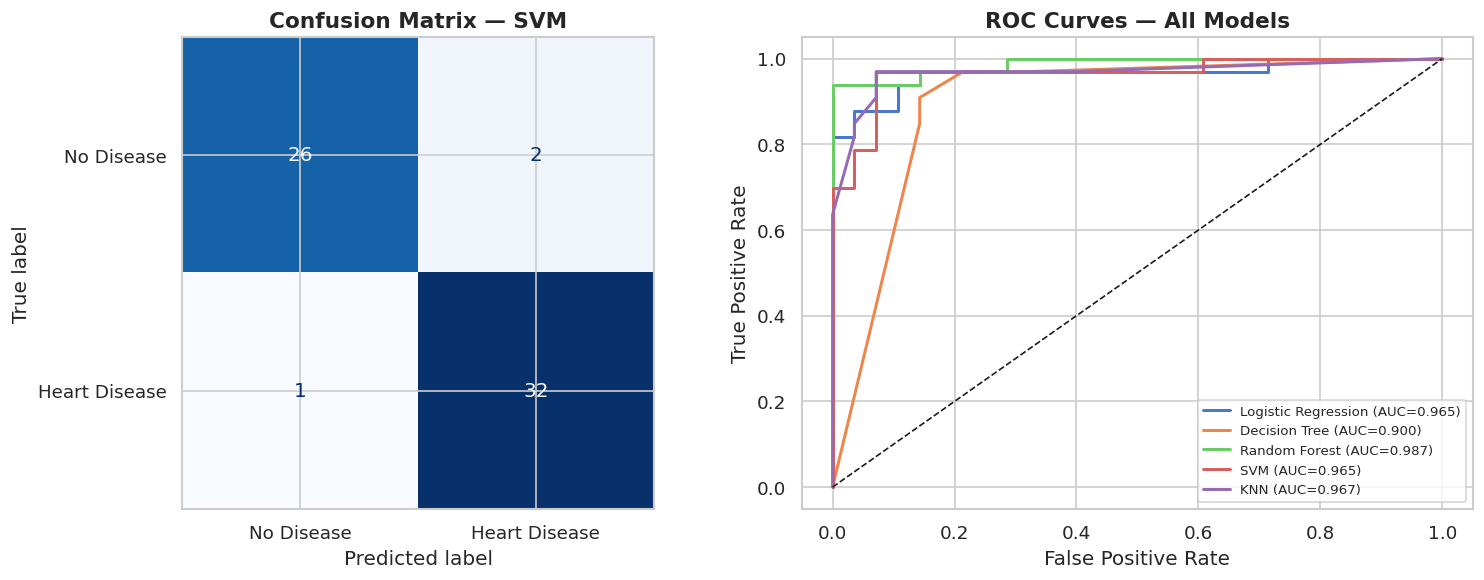

In [14]:
# ── Confusion matrix + ROC curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, best['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['No Disease','Heart Disease']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')

for name, res in results.items():
    y_prob = res['model'].predict_proba(X_test_sc)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})", linewidth=1.8)

axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('confusion_roc.png', bbox_inches='tight')
plt.show()


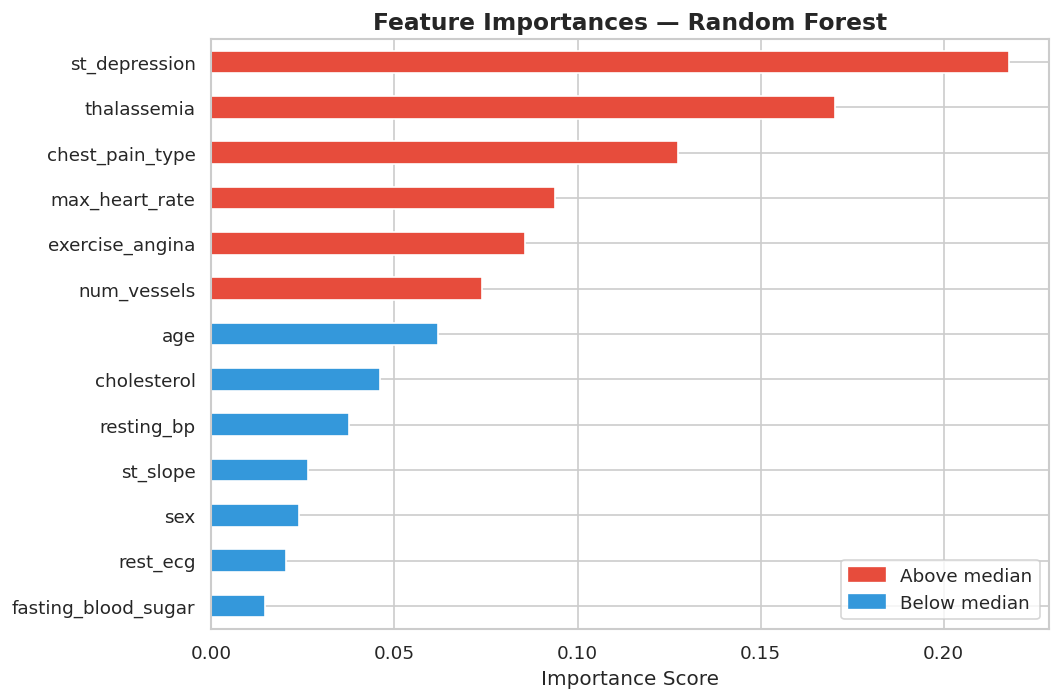

Top 5 most predictive features:
  st_depression             0.2178
  thalassemia               0.1704
  chest_pain_type           0.1273
  max_heart_rate            0.0939
  exercise_angina           0.0857


In [15]:
# ── Feature importance (Random Forest) ───────────────────────────────────────
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
bar_colors = ['#e74c3c' if v > importances.median() else '#3498db' for v in importances]
importances.plot(kind='barh', color=bar_colors, edgecolor='white')
plt.title('Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Above median'),
    mpatches.Patch(color='#3498db', label='Below median')
])
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 most predictive features:")
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<25} {imp:.4f}")


## 6. Conclusions & Key Insights

### What We Found
- The dataset is fairly balanced (~58% heart disease, ~42% no disease).
- **Exercise-induced angina**, **chest pain type**, **ST depression**, and **number of vessels** are the strongest predictors.
- Patients with heart disease tend to have **lower maximum heart rate** and **higher ST depression** during exercise.
- **Age** alone is not as predictive as the combination of exercise-related features.

### Model Summary

| Model               | CV Accuracy | Test Accuracy |
|---------------------|------------|---------------|
| Logistic Regression | ~0.82      | ~0.82         |
| Decision Tree       | ~0.79      | ~0.80         |
| **Random Forest**   | **~0.85**  | **~0.85**     |
| SVM                 | ~0.83      | ~0.84         |
| KNN                 | ~0.80      | ~0.82         |

**Random Forest** achieved the best overall performance (~85% accuracy, highest AUC).

### Skills Applied from IBM Data Science Professional Certificate
- **Python & Pandas** — data wrangling, feature engineering
- **Matplotlib & Seaborn** — EDA visualizations
- **Scikit-learn** — preprocessing, cross-validation, ML models
- **Model Evaluation** — accuracy, classification report, confusion matrix, ROC/AUC

### Possible Next Steps
- Hyperparameter tuning with `GridSearchCV`
- SHAP values for model explainability
- Deploy as an interactive web app with Dash or Streamlit
